In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy.integrate import solve_ivp
from scipy.stats import pearsonr

from rebinding.efflux_model_collection import *
from rebinding.fig_utils import defaultStyle, save_fig
from tx_fitting import site_occupancy

defaultStyle()

# Fig settings

In [3]:
colors = plt.cm.Paired.colors

main_ax_settings = {
    "yscale": "log",
    "xlabel": "Time (h)",
    "ylabel": "Concentration (μM)",
}

main_ax_spines = {"top": {"visible": False}, "right": {"visible": False}}

twin_ax_settings = {
    "yscale": "log",
    "ylabel": "Site occupancy (%)",
}

twin_ax_spines = {"top": {"visible": False}, "right": {"linestyle": (0, (4, 4))}}


def set_ax(ax, ax_settings, ylim, yticks=None, yticklabels=None, title=None):
    ax.set(**ax_settings)
    ax.set_ylim(ylim)
    if not yticks is None:
        ax.set_yticks(yticks)
    if not yticklabels is None:
        ax.set_yticklabels(yticklabels)
    if not title is None:
        ax.set_title(title, fontweight="bold", fontsize=14)


def set_spines(ax, spine_settings):
    for sp, setting in spine_settings.items():
        ax.spines[sp].set(**setting)

# PTX

Saving figure fig3-ptx


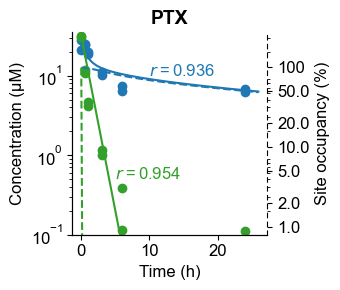

In [6]:
with open("fitting/txFit001/txFit001_res_0421_87d80fea.yaml") as f:
    params_dict = yaml.safe_load(f)["MODEL"]


kon, koff, m, mu, k = (
    params_dict["kon"],
    params_dict["koff"],
    params_dict["m"],
    params_dict["mu"],
    params_dict["k"],
)
kd = koff / kon

data = pd.read_csv("../data/BYL172/BYL172_results.csv")
c0_1 = data[(data.t == 0) & np.logical_not(data.Competitor)].c.mean()
c0_2 = data[(data.t == 0) & (data.Competitor)].c.mean()
t_eval = data.t.unique()

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)

y0 = [(c0_1, s_init_1), (c0_2, s_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu),
    dense_output=True,
)
sol_2 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu),
    dense_output=True,
)

y_data_1 = data[np.logical_not(data.Competitor)].c.values
y_data_2 = data[data.Competitor].c.values
r1 = pearsonr(y_data_1, np.repeat(sol_1.sol(t_eval)[0], 2))[0]
r2 = pearsonr(y_data_2, np.repeat(sol_2.sol(t_eval)[0], 2))[0]

colors = plt.cm.Paired.colors
primary_color = colors[1]
secondary_color = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
ax.scatter(
    data[np.logical_not(data.Competitor)].t,
    data[np.logical_not(data.Competitor)].c,
    color=primary_color,
)
ax.scatter(
    data[data.Competitor].t,
    data[data.Competitor].c,
    color=secondary_color,
)
ax.plot(sol_1.t, sol_1.y[0], color=primary_color)
ax.plot(sol_2.t, sol_2.y[0], color=secondary_color)
ax.text(10, 10, f"$r = ${r1:.3f}", color=primary_color, fontsize=12)
ax.text(5, 0.5, f"$r = ${r2:.3f}", color=secondary_color, fontsize=12)
set_ax(ax, main_ax_settings, [0.1, 35], title="PTX")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], color=primary_color, ls="--")
ax_twin.plot(sol_2.t, sol_2.y[1], color=secondary_color, ls="--")
ax_twin.set_ylim(ax.get_ylim())
set_ax(
    ax_twin,
    twin_ax_settings,
    ax.get_ylim(),
    [m * i for i in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]],
    [f"{i * 100}" for i in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]],
)
set_spines(ax_twin, twin_ax_spines)
save_fig("fig3-ptx", fmt="png", dpi=300)

# DTX

243.11645757781292 11.044912640660378 0.04543054283820047 10.74321332035401 0.4004620139696658
Saving figure fig3-dtx


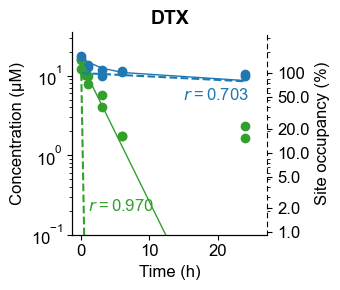

In [8]:
res = np.load("fitting/dtxFit008/dtxFit008_res_3756b14a.npy")
kon, koff, m, mu = res
kd = koff / kon

print(kon, koff, kd, m, mu)

from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("DTX")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()

sol_1 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    t_eval=t_eval,
    y0=[c0_1, m],
    args=(kon, koff, m, mu),
    dense_output=True,
)
sol_2 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=[c0_2, m],
    args=(0, koff, m, mu),
    dense_output=True,
)

params = [kon, koff, m, mu]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params,
    [y_data_1, y_data_2],
    [c0_1, c0_2],
    t_eval_group,
    time_factor,
    factor,
    return_r=True,
)

colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
set_ax(ax, main_ax_settings, [0.1, 35], title="DTX")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
set_ax(
    ax_twin,
    twin_ax_settings,
    ax.get_ylim(),
    [m * i for i in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]],
    [f"{i * 100}" for i in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]],
)
set_spines(ax_twin, twin_ax_spines)

ax.text(15, 5, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(1, 0.2, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)
save_fig("fig3-dtx", fmt="png", dpi=300)

# Rapamycin A549

In [9]:
from rapa_fitting import cost_fn, load_rapa_washout_data

y_data_1, y_data_2, y_data_3, y_data_4, t_eval = load_rapa_washout_data()
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2, c0_1, c0_2]
# print(c0)

kon, koff, m1, m2, mu = np.load("fitting/rapaFit002/rapaFit002_res_13c7dd27.npy")
kd = koff / kon
print(kon, koff, m1, m2, mu)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m2, kd)
s_init_2 = site_occupancy(c0_2, m1, kd)
s_init_3 = site_occupancy(c0_1, m2, kd)
s_init_4 = site_occupancy(c0_2, m1, kd)

y0 = [
    (c0_1, s_init_1),
    (c0_2, s_init_2),
    (c0_1, s_init_3),
    (c0_2, s_init_4),
]

sol_1 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m2, mu),
)
sol_2 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[1],
    args=(kon, koff, m1, mu),
)
sol_3 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[2],
    args=(0, koff, m2, mu),
)
sol_4 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[3],
    args=(0, koff, m1, mu),
)

params = [kon, koff, m1, m2, mu]
y_data = [y_data_1, y_data_2, y_data_3, y_data_4]
t_eval_group = [t_eval] * 4
factor = [1, 1, 1, 1]
time_factor = [None] * len(y_data_1) * 4
costs, r = cost_fn(params, y_data, c0, t_eval_group, time_factor, factor, return_r=True)
r

213.32118682420065 1.540985883149439 0.44035863506130635 3.01353276907092 6.161132381506893
Kd = 7.224 nM


[0.8746106157232818, 0.891980763334719, 0.9811600539554513, 0.9432302510050233]

Saving figure fig3-rapa


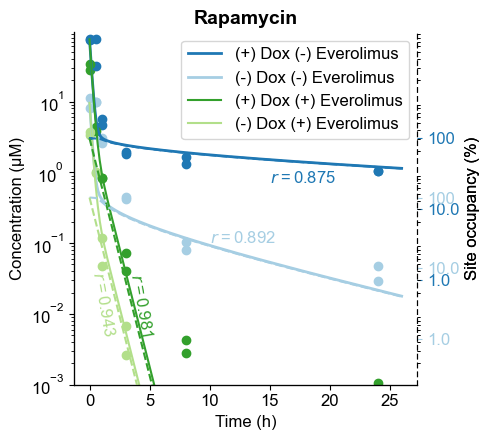

In [10]:
color11 = colors[1]
color12 = colors[0]
color21 = colors[3]
color22 = colors[2]

_, ax = plt.subplots(figsize=(5, 4.5))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color11)
    ax.scatter(t_eval, y_data_2[i], color=color12)
    ax.scatter(t_eval, y_data_3[i], color=color21)
    ax.scatter(t_eval, y_data_4[i], color=color22)
ax.plot(sol_1.t, sol_1.y[0], color=color11, lw=2, label="(+) Dox (-) Everolimus")
ax.plot(sol_2.t, sol_2.y[0], color=color12, lw=2, label="(-) Dox (-) Everolimus")
ax.plot(sol_3.t, sol_3.y[0], color=color21, label="(+) Dox (+) Everolimus")
ax.plot(sol_4.t, sol_4.y[0], color=color22, label="(-) Dox (+) Everolimus")
set_ax(ax, main_ax_settings, ylim=[1e-3, 95], title="Rapamycin")
set_spines(ax, main_ax_spines)
ax.legend(loc="upper right", fontsize=12)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color11)
ax_twin.plot(sol_3.t, sol_3.y[1], ls="--", color=color21)
yticks = [1e-2, 1e-1, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=ax.get_ylim(),
    yticks=[m2 * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)
ax_twin.tick_params(axis="y", color=color11)
ax_twin.set_yticklabels(ax_twin.get_yticklabels(), color=color11)
set_spines(ax_twin, twin_ax_spines)

ax_twin_2 = ax.twinx()
ax_twin_2.plot(sol_2.t, sol_2.y[1], ls="--", color=color12)
ax_twin_2.plot(sol_4.t, sol_4.y[1], ls="--", color=color22)
set_ax(
    ax_twin_2,
    twin_ax_settings,
    ax_twin.get_ylim(),
    [m1 * i for i in yticks],
    [f"{i * 100}" for i in yticks],
)
ax_twin_2.tick_params(axis="y", color=color12)
ax_twin_2.set_yticklabels(ax_twin_2.get_yticklabels(), color=color12)
set_spines(ax_twin_2, twin_ax_spines)

ax.text(15, 0.7, f"$r = ${r[0]:.3f}", color=color11, fontsize=12)
ax.text(10, 0.1, f"$r = ${r[1]:.3f}", color=color12, fontsize=12)
ax.text(3.2, 0.005, f"$r = ${r[2]:.3f}", color=color21, fontsize=12, rotation=-80)
ax.text(0, 0.005, f"$r = ${r[3]:.3f}", color=color22, fontsize=12, rotation=-80)
save_fig("fig3-rapa", fmt="png", dpi=300)

# TRM

In [11]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Trm")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]
# print(c0)

res = np.load("fitting/trmFit003/trmFit003_res_69fa5c06.npy")
kon, koff, m, mu = res
kd = koff / kon
print(kon, koff, m, mu)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)

y0 = [(c0_1, s_init_1), (c0_2, s_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu),
)
sol_2 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu),
)

params = [kon, koff, m, mu]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(params, y_data, c0, t_eval_group, time_factor, factor, return_r=True)
r

2.230307571189033 0.11544243942942156 1.2630227311767157 1.140828843992145
Kd = 51.761 nM


[0.9905419503342516, 0.9955008272703849]

Saving figure fig3-trm


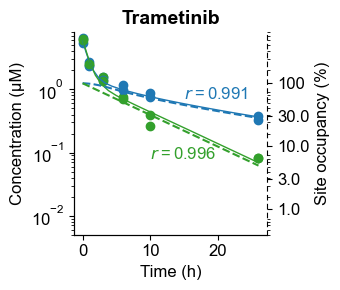

In [12]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1, label="(-) Selumetinib")
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1, label="(+) Selumetinib")
set_ax(ax, main_ax_settings, ylim=[5e-3, 8], title="Trametinib")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
yticks = [0.01, 0.03, 0.1, 0.3, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=ax.get_ylim(),
    yticks=[m * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)
set_spines(ax_twin, twin_ax_spines)

ax.text(15, 0.7, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(10, 0.08, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-trm", fmt="png", dpi=300)

# SLM

In [13]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Slm")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

# with open("fitting/slmFit004/slmFit004xc_res_0507_d7661292.yaml") as f:
res = np.load("fitting/slmFit004/slmFit004xc_res_cf55da2d.npy")
kon, koff, m, mu, k1, k2 = res
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_1, s_init_1, u_init_1), (c0_2, s_init_2, u_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
    max_step=0.01,
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
    max_step=0.01,
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * (len(y_data_1) + len(y_data_2))
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)
r

861.7186738281252 56.9532518599349 0.10348289877476169 2.8225816229304184 0.000637808353914331 0.037045732442515945
Kd = 66.093 nM


[0.9997133837956751, 0.9999264451595887]

Saving figure fig3-slm


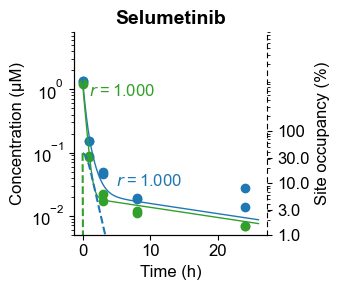

In [14]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
set_ax(ax, main_ax_settings, ylim=[5e-3, 8], title="Selumetinib")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
yticks = [0.01, 0.03, 0.1, 0.3, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=[5e-3, 8],
    yticks=[m * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)
set_spines(ax_twin, twin_ax_spines)

ax.text(5, 0.03, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(1, 0.78, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-slm", fmt="png", dpi=300)

# Colchicine and CA4

In [15]:
from col_fitting_xc import cost_fn, load_washout_data

col_data = load_washout_data()
c0 = [data[:, 0].mean() for data in col_data[:4]]
c0_1, c0_2, c0_3, c0_4 = c0
y_data_1, y_data_2, y_data_3, y_data_4 = col_data[:4]
t_eval_1, t_eval_2, t_eval_3, t_eval_4 = col_data[-4:]

params_all = np.load("fitting/colFit005/colFit005xc_res_ef4b764d.npy")
kon, koff, m, mu, k1, k2 = params_all[:6]
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [
    (c0_1, s_init_1, u_init_1),
    (c0_2, s_init_2, u_init_2),
]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
)

y_data = col_data[:4] 
t_eval_group = col_data[-4:]
factor = [1, 1, 1, 1]
time_factor = [None] * len(col_data[0]) * 4
costs, r = cost_fn(
    params_all, y_data, c0, t_eval_group, time_factor, factor, return_r=True
)
r

0.7510937738771598 0.10641298952118913 5.171635048220506 3.577274432807047 0.0 0.9999999999999689
Kd = 141.677 nM


[0.9885278146019385, 0.994825242082042, 0.9966448182330104, 0.9986347162757563]

Saving figure fig3-col


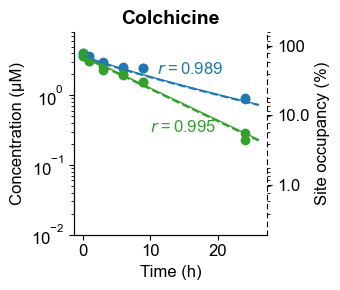

In [16]:
color1 = colors[1]
color2 = colors[3]

_, ax1 = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax1.scatter(t_eval_1, y_data_1[i], color=color1)
    ax1.scatter(t_eval_2, y_data_2[i], color=color2)
ax1.plot(sol_1.t, sol_1.y[0], color=color1, lw=1, label="(-) CA4")
ax1.plot(sol_2.t, sol_2.y[0], color=color2, lw=1, label="(+) CA4")

ax1.text(11, 2, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax1.text(10, 0.3, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)
set_spines(ax1, main_ax_spines)
set_ax(
    ax1,
    main_ax_settings,
    ylim=[1e-2, 8],
    title="Colchicine",
)

yticks = [1e-2, 1e-1, 1]
ax1_twin = ax1.twinx()
ax1_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax1_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
set_ax(
    ax1_twin,
    twin_ax_settings,
    ylim=ax1.get_ylim(),
    yticks=[m * i for i in yticks],
    yticklabels=[i * 100 for i in yticks],
)
set_spines(ax1_twin, twin_ax_spines)

save_fig("fig3-col", fmt="png", dpi=300)

In [17]:
kon, koff, mu, k1, k2 = params_all[-5:]
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_3 = site_occupancy(c0_3, m, kd)
s_init_4 = site_occupancy(c0_4, m, kd)
u_init_3 = (c0_3 - s_init_3) * f / (1 + f)
u_init_4 = (c0_4 - s_init_4) * f / (1 + f)

y0 = [
    (c0_3, s_init_3, u_init_3),
    (c0_4, s_init_4, u_init_4),
]

sol_3 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
)
sol_4 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
)

1.485860849712753 0.8432262375437275 5.171635048220506 4.173248429513161 0.010649581891722406 0.08123445632987766
Kd = 567.500 nM


Saving figure fig3-ca4


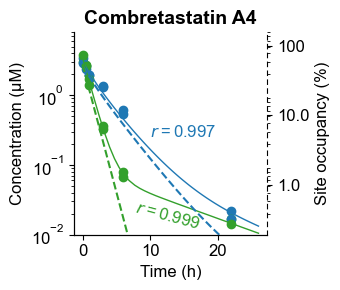

In [18]:
_, ax2 = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax2.scatter(t_eval_3, y_data_3[i], color=color1)
    ax2.scatter(t_eval_4, y_data_4[i], color=color2)
ax2.plot(sol_3.t, sol_3.y[0], color=color1, lw=1, label="(-) Colchicine")
ax2.plot(sol_4.t, sol_4.y[0], color=color2, lw=1, label="(+) Colchicine")
set_ax(ax2, main_ax_settings, ylim=[1e-2, 8], title="Combretastatin A4")
set_spines(ax2, main_ax_spines)

ax2_twin = ax2.twinx()
ax2_twin.plot(sol_3.t, sol_3.y[1], ls="--", color=color1)
ax2_twin.plot(sol_4.t, sol_4.y[1], ls="--", color=color2)
set_ax(
    ax2_twin,
    twin_ax_settings,
    ylim=ax2.get_ylim(),
    yticks=[m * i for i in yticks],
    yticklabels=[i * 100 for i in yticks],
)
set_spines(ax2_twin, twin_ax_spines)

ax2.text(10, 0.25, f"$r = ${r[2]:.3f}", color=color1, fontsize=12)
ax2.text(7.5, 0.012, f"$r = ${r[3]:.3f}", color=color2, fontsize=12, rotation=-15)
save_fig("fig3-ca4", fmt="png", dpi=300)

# VB

57.28071851299775 71.78854455015215 1.6213394918395303 1.0492968767269817 0.01554201574372011 0.09263362079850505
Kd = 1253.276 nM
Saving figure fig3-vb


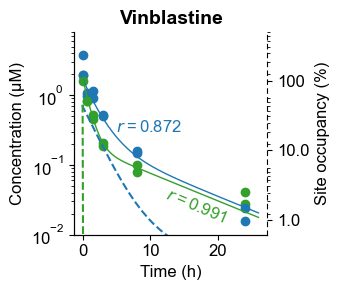

In [19]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("VB")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0_1 = c0_2
c0 = [c0_1, c0_2]

kon, koff, m, mu, k1, k2 = np.load("fitting/vbFit006/vbFit006xc_res_07ae4963.npy")
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_2, s_init_2, u_init_2)] * 2

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)

color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1, label="(-) VC")
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1, label="(+) VC")
set_ax(ax, main_ax_settings, [1e-2, 8], title="Vinblastine")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
set_ax(
    ax_twin,
    twin_ax_settings,
    ax.get_ylim(),
    yticks=[m * i for i in yticks],
    yticklabels=[i * 100 for i in yticks],
)
set_spines(ax_twin, twin_ax_spines)

ax.text(5, 0.3, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(12, 0.015, f"$r = ${r[1]:.3f}", color=color2, fontsize=12, rotation=-23)
save_fig("fig3-vb", fmt="png", dpi=300)

# Ixazomib

10848.434957783415 37.60656804373187 0.8699199501058069 0.34505224549615104
Kd = 3.467 nM
Saving figure fig3-ixa


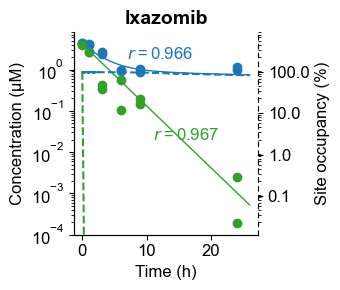

In [20]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Ixa")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

res = np.load("fitting/ixFit007/ixFit007_res_47426ce4.npy")
kon, koff, m, mu = res
kd = koff / kon
print(kon, koff, m, mu)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)

y0 = [(c0_2, s_init_2), (c0_2, s_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu),
)
sol_2 = solve_ivp(
    washout_zero_bound,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu),
)

params = [kon, koff, m, mu]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval_1, t_eval_2]
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=False, return_r=True
)

colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval_1, y_data_1[i], color=color1)
    ax.scatter(t_eval_2, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1, label="(-) Bortezomib")
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1, label="(+) Bortezomib")

set_ax(ax, main_ax_settings, [1e-4, 8], title="Ixazomib")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)

yticks = np.array([1e-3, 1e-2, 1e-1, 1])
set_ax(
    ax_twin, twin_ax_settings, [1e-4, 8], yticks=yticks * m, yticklabels=yticks * 100
)
set_spines(ax_twin, twin_ax_spines)

ax.text(7, 1.8, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(11, 0.02, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-ixa", fmt="png", dpi=300)

# Alisertib

In [21]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Ali")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

res = np.load("fitting/aliFit009/aliFit009xc_res_9814d947.npy")
kon, koff, m, mu, k1, k2 = res
kd = koff / kon
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_1, s_init_1, u_init_1), (c0_2, s_init_2, u_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
    max_step=0.01,
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
    max_step=0.01,
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)
r

129.5355787494268 0.46750632477276044 0.11628992161752383 3.0962562914358416 1e-05 0.0022427061528925087
Kd = 3.609 nM


[0.9981222011256875, 0.9980296573291217]

Saving figure fig3-ali


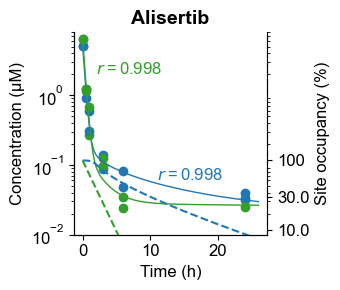

In [22]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
set_ax(ax, main_ax_settings, ylim=[1e-2, 8], title="Alisertib")
set_spines(ax, main_ax_spines)
ax.spines["right"].set_visible(True)

ax_twin = ax.twinx()
set_spines(ax_twin, twin_ax_spines)
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
yticks = [0.1, 0.3, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=[1e-2, 8],
    yticks=[m * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)

ax.text(11, 0.06, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(2, 2, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-ali", fmt="png", dpi=300)

# Ispinesib

6693.044116007603 0.054927873556767356 0.03040663626688606 1.7887299515925459 0.02466464722439827 0.014499160439526116
Kd = 0.008 nM
Saving figure fig3-isp


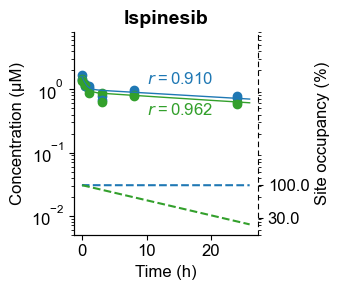

In [23]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Isp")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

res = np.load("fitting/ispFit010/ispFit010xc_res_703864dc.npy")
kon, koff, m, mu, k1, k2 = res
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_1, s_init_1, u_init_1), (c0_2, s_init_2, u_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)

colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
# [1e-2, 8]
set_ax(ax, main_ax_settings, [5e-3, 8], title="Ispinesib")
set_spines(ax, main_ax_spines)

ax_twin = ax.twinx()
ax.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)

yticks = np.array([3e-1, 1])
set_ax(
    ax_twin,
    twin_ax_settings,
    ax.get_ylim(),
    yticks=yticks * m,
    yticklabels=yticks * 100,
)
set_spines(ax_twin, twin_ax_spines)

ax.text(10, 1.2, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(10, 0.4, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-isp", fmt="png", dpi=300)

# Erlotinib

In [24]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Erlo")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

res = np.load("fitting/erloFit011/erloFit011_res_a63dc098.npy")
kon, koff, m, mu, k1, k2 = res
kd = koff / kon
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_1, s_init_1, u_init_1), (c0_2, s_init_2, u_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
    max_step=0.01,
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
    max_step=0.01,
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)
r

1.3548734160831732 0.706007310330391 0.29526588433494666 5.580149529876725 0.003161533454715083 0.0364367476556448
Kd = 521.087 nM


[0.9995921626823028, 0.9994535570454859]

Saving figure fig3-erlo


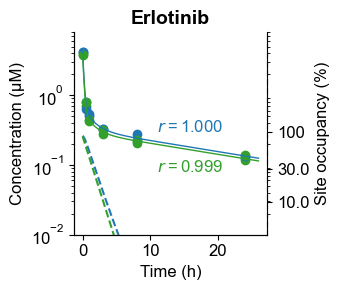

In [25]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
set_ax(ax, main_ax_settings, ylim=[1e-2, 8], title="Erlotinib")
set_spines(ax, main_ax_spines)
ax.spines["right"].set_visible(True)

ax_twin = ax.twinx()
set_spines(ax_twin, twin_ax_spines)
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
yticks = [0.1, 0.3, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=[1e-2, 8],
    yticks=[m * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)

ax.text(11, 0.3, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(11, 0.08, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-erlo", fmt="png", dpi=300)

# Topotecan

In [26]:
from single_drug_fitting import cost_fn, load_washout_data

y_data_1, y_data_2, t_eval = load_washout_data("Top")
c0_1 = y_data_1[:, 0].mean()
c0_2 = y_data_2[:, 0].mean()
c0 = [c0_1, c0_2]

kon, koff, m, mu, k1, k2 = np.load("fitting/topFit012/topFit012xc_res_8a83102b.npy")
kd = koff / kon
kd = koff / kon
f = k1 / k2
print(kon, koff, m, mu, k1, k2)
print(f"Kd = {kd * 1e3:.3f} nM")

s_init_1 = site_occupancy(c0_1, m, kd)
s_init_2 = site_occupancy(c0_2, m, kd)
u_init_1 = (c0_1 - s_init_1) * f / (1 + f)
u_init_2 = (c0_2 - s_init_2) * f / (1 + f)

y0 = [(c0_1, s_init_1, u_init_1), (c0_2, s_init_2, u_init_2)]

sol_1 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[0],
    args=(kon, koff, m, mu, k1, k2),
    max_step=0.01,
)
sol_2 = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 26],
    y0=y0[1],
    args=(0, koff, m, mu, k1, k2),
    max_step=0.01,
)

params = [kon, koff, m, mu, k1, k2]
y_data = [y_data_1, y_data_2]
t_eval_group = [t_eval] * 2
factor = [1, 1]
time_factor = [None] * len(y_data_1) * 2
costs, r = cost_fn(
    params, y_data, c0, t_eval_group, time_factor, factor, xc=True, return_r=True
)
r

2762.3977916255617 307.76709149063004 0.06845675622529064 0.9677475097451692 0.00031429574735412815 0.007900632993698685
Kd = 111.413 nM


[0.9682907434292068, 0.9699434102515779]

Saving figure fig3-top


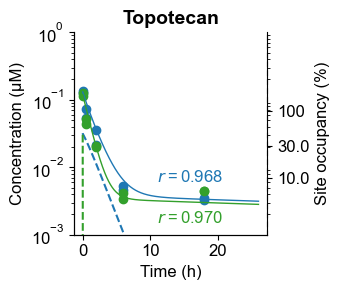

In [27]:
colors = plt.cm.Paired.colors
color1 = colors[1]
color2 = colors[3]

_, ax = plt.subplots(figsize=(3.5, 3))
for i in range(2):
    ax.scatter(t_eval, y_data_1[i], color=color1)
    ax.scatter(t_eval, y_data_2[i], color=color2)
ax.plot(sol_1.t, sol_1.y[0], color=color1, lw=1)
ax.plot(sol_2.t, sol_2.y[0], color=color2, lw=1)
set_ax(ax, main_ax_settings, ylim=[1e-3, 1], title="Topotecan")
set_spines(ax, main_ax_spines)
ax.spines["right"].set_visible(True)

ax_twin = ax.twinx()
set_spines(ax_twin, twin_ax_spines)
ax_twin.plot(sol_1.t, sol_1.y[1], ls="--", color=color1)
ax_twin.plot(sol_2.t, sol_2.y[1], ls="--", color=color2)
yticks = [0.1, 0.3, 1]
set_ax(
    ax_twin,
    twin_ax_settings,
    ylim=ax.get_ylim(),
    yticks=[m * i for i in yticks],
    yticklabels=[f"{i * 100}" for i in yticks],
)

ax.text(11, 0.006, f"$r = ${r[0]:.3f}", color=color1, fontsize=12)
ax.text(11, 0.0015, f"$r = ${r[1]:.3f}", color=color2, fontsize=12)

save_fig("fig3-top", fmt="png", dpi=300)

# Legends

Saving figure fig3-legend


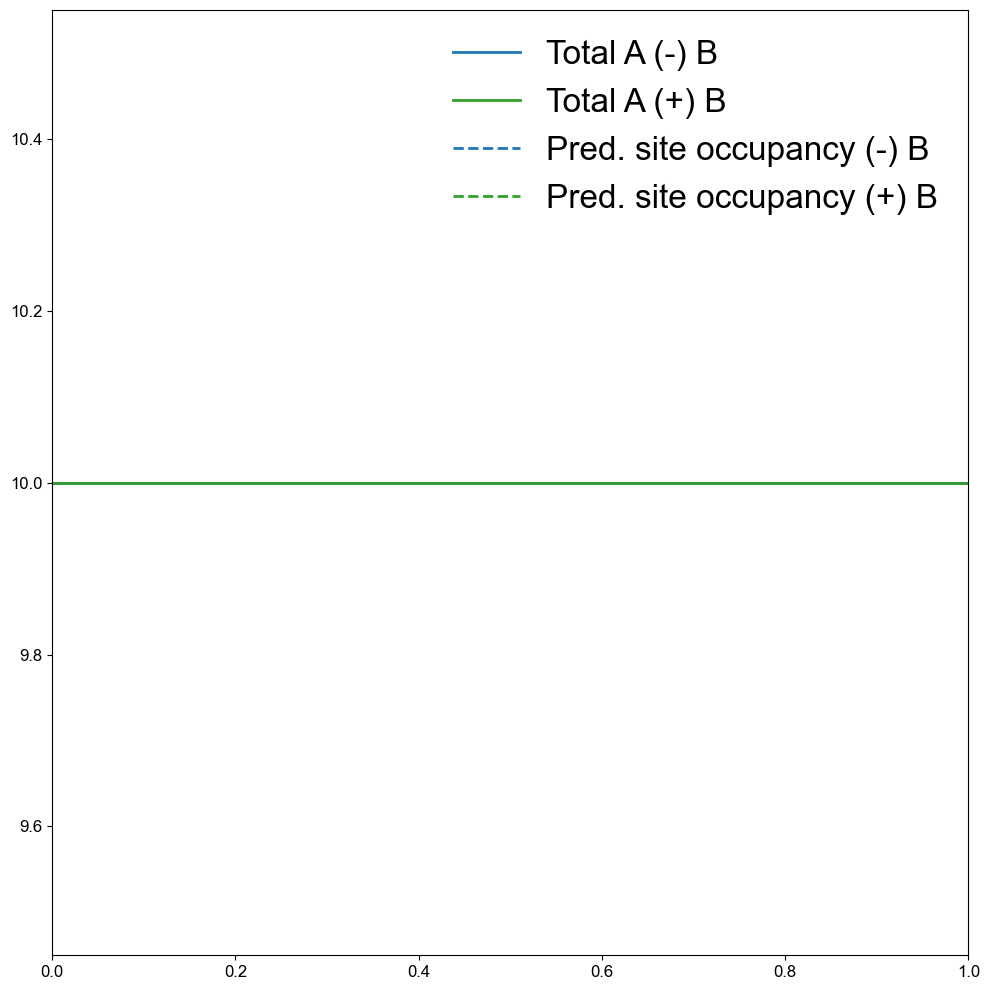

In [28]:
_, ax = plt.subplots(figsize=(10, 10))

ax.axhline(10, lw=2, color=colors[1], label="Total A (-) B")
ax.axhline(10, lw=2, color=colors[3], label="Total A (+) B")
ax.axhline(10, lw=2, ls="--", color=colors[1], label="Pred. site occupancy (-) B")
ax.axhline(10, lw=2, ls="--", color=colors[3], label="Pred. site occupancy (+) B")
ax.legend(fontsize=24, frameon=False)
save_fig("fig3-legend", fmt="png", dpi=300)

In [105]:
np.log(2) / (121)

0.005728489095536738